In [13]:
# Colab에서 한글 폰트 설치
!apt-get -qq update
!apt-get -qq install -y fonts-nanum

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import shutil
import os

# matplotlib font cache 삭제
shutil.rmtree(mpl.get_cachedir(), ignore_errors=True)

# NanumGothic 직접 등록
font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fm.fontManager.addfont(font_path)

mpl.rcParams['font.family'] = 'NanumGothic'
mpl.rcParams['axes.unicode_minus'] = False

print("NanumGothic font setting complete.")

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
NanumGothic font setting complete.


In [14]:
# =========================================================
# 0. 기본 설정
# =========================================================

import os
import gc
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# 새로운 데이터 import
weather = pd.read_csv('/content/drive/MyDrive/2026_기상청_축산/hanwoo_weather.csv')

In [15]:
################
# 결측치 표준화 - -99, -99.0을 NaN으로 표준화
################

def replace_minus99_to_nan(df):
    df = df.copy()

    for col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            df[col] = df[col].mask(df[col].isin([-99, -99.0]), np.nan)
        else:
            df[col] = (
                df[col]
                .astype("string")
                .str.strip()
                .replace(r"^-99(\.0+)?$", np.nan, regex=True)
            )

    return df


weather = replace_minus99_to_nan(weather)

In [5]:
print('결측치 확인 (weather 데이터프레임):')
display(weather.isnull().sum())

결측치 확인 (weather 데이터프레임):


,0
stn,0
date,0
ta_max,12364
rn_day,15993
ta_min,12364
rhm_avg,48155
ws_davg,13602


In [6]:
print(weather.shape[0])

973248


## [1] 결측치 간 관계 확인

### 1-1. 수치형 컬럼 상관관계

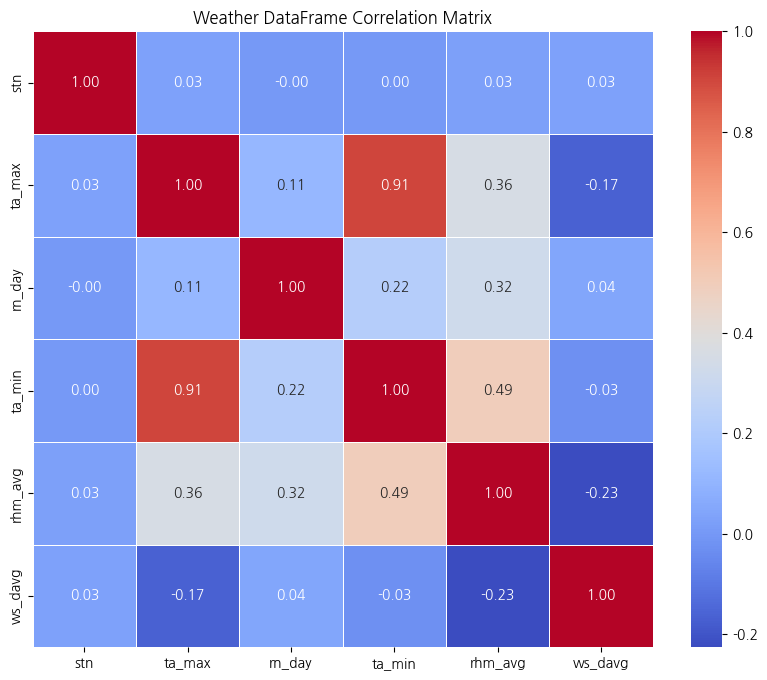

In [16]:
# weather 데이터프레임의 수치형 컬럼들 간의 상관관계 계산 - 전체
weather_corr = weather.select_dtypes(include=[np.number]).corr()
# 기상 변수끼리의 상관계수
plt.figure(figsize=(10, 8))
sns.heatmap(weather_corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Weather DataFrame Correlation Matrix')
plt.show()

### 1-2. 결측치간 상관관계

In [17]:
# 결측치 들만 따로 저장

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import combinations

# 사용할 변수
cols = ['ta_max', 'rn_day', 'ta_min', 'rhm_avg', 'ws_davg']

# 원본 복사 + 결측 처리
w = weather.copy()
w = w.replace([-99, -99.0, -999, -999.0], np.nan)

# 실제 존재하는 컬럼만 사용
cols = [c for c in cols if c in w.columns]

# 1. 변수별 결측 개수/비율
missing_summary = pd.DataFrame({
    'missing_count': w[cols].isna().sum(),
    'missing_rate': w[cols].isna().mean()
}).sort_values('missing_rate', ascending=False)

display(missing_summary)

,missing_count,missing_rate
rhm_avg,48155,0.049479
rn_day,15993,0.016433
ws_davg,13602,0.013976
ta_max,12364,0.012704
ta_min,12364,0.012704


,ta_max,rn_day,ta_min,rhm_avg,ws_davg
ta_max,1.000000,0.861500,1.000000,0.109962,0.165781
rn_day,0.861500,1.000000,0.861500,0.093083,0.148950
ta_min,1.000000,0.861500,1.000000,0.109962,0.165781
rhm_avg,0.109962,0.093083,0.109962,1.000000,0.179522
ws_davg,0.165781,0.148950,0.165781,0.179522,1.000000


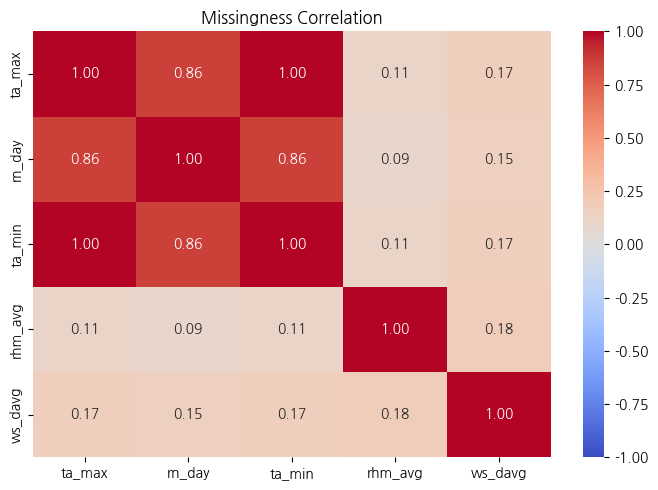

In [18]:
# 2. 결측 여부 상관계수
miss = w[cols].isna().astype(int)

missing_corr = miss.corr()

display(missing_corr)

plt.figure(figsize=(7, 5))
sns.heatmap(
    missing_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)
plt.title("Missingness Correlation")
plt.tight_layout()
plt.show()

### 2-3. 변수간 동시 결측 확인

In [19]:
# 변수 쌍별 동시결측 비율 확인
pair_rows = []

for a, b in combinations(cols, 2):
    A = w[a].isna()
    B = w[b].isna()

    n_a = A.sum()
    n_b = B.sum()
    n_both = (A & B).sum()
    n_either = (A | B).sum()

    pair_rows.append({
        'var_a': a,
        'var_b': b,
        'a_missing': n_a,
        'b_missing': n_b,
        'both_missing': n_both,
        'p_b_missing_given_a_missing': n_both / n_a if n_a > 0 else np.nan,
        'p_a_missing_given_b_missing': n_both / n_b if n_b > 0 else np.nan,
        'jaccard': n_both / n_either if n_either > 0 else np.nan,
        'missing_corr': miss[[a, b]].corr().iloc[0, 1]
    })

pair_summary = pd.DataFrame(pair_rows).sort_values(
    ['missing_corr', 'jaccard', 'both_missing'],
    ascending=False
)

display(pair_summary)

,var_a,var_b,a_missing,b_missing,both_missing,p_b_missing_given_a_missing,p_a_missing_given_b_missing,jaccard,missing_corr
1,ta_max,ta_min,12364,12364,12364,1.000000,1.000000,1.000000,1.000000
0,ta_max,rn_day,12364,15993,12141,0.981964,0.759145,0.748705,0.861500
4,rn_day,ta_min,15993,12364,12141,0.759145,0.981964,0.748705,0.861500
9,rhm_avg,ws_davg,48155,13602,5121,0.106344,0.376489,0.090420,0.179522
3,ta_max,ws_davg,12364,13602,2294,0.185539,0.168652,0.096908,0.165781
8,ta_min,ws_davg,12364,13602,2294,0.185539,0.168652,0.096908,0.165781
6,rn_day,ws_davg,15993,13602,2387,0.149253,0.175489,0.087732,0.148950
2,ta_max,rhm_avg,12364,48155,3211,0.259706,0.066681,0.056031,0.109962
7,ta_min,rhm_avg,12364,48155,3211,0.259706,0.066681,0.056031,0.109962
5,rn_day,rhm_avg,15993,48155,3289,0.205652,0.068300,0.054043,0.093083


In [20]:
# 어떤 변수 조합으로 결측이 자주 발생하는지 확인
missing_patterns = (
    w[cols]
    .isna()
    .apply(lambda row: '+'.join(row.index[row]) if row.any() else 'no_missing', axis=1)
    .value_counts()
    .reset_index()
)

missing_patterns.columns = ['missing_pattern', 'count']
missing_patterns['ratio'] = missing_patterns['count'] / len(w)

display(missing_patterns.head(30))

,missing_pattern,count,ratio
0,no_missing,903802,0.928645
1,rhm_avg,42038,0.043194
2,ta_max+rn_day+ta_min,8955,0.009201
3,ws_davg,8423,0.008655
4,rn_day,3695,0.003797
5,rhm_avg+ws_davg,2769,0.002845
6,ta_max+rn_day+ta_min+rhm_avg+ws_davg,2237,0.002298
7,ta_max+rn_day+ta_min+rhm_avg,915,0.000940
8,ta_max+ta_min,160,0.000164
9,rn_day+rhm_avg+ws_davg,96,0.000099


### 2-4 장기 결측 확인

In [21]:
import pandas as pd
import numpy as np

df = weather.copy()

df["date"] = pd.to_datetime(df["date"])
df["stn"] = df["stn"].astype(int)
df = df.sort_values(["stn", "date"]).reset_index(drop=True)

weather_cols = ["ta_max", "ta_min", "rhm_avg", "ws_davg", "rn_day"] # 결측이 있는 컬럼만 가져오기
LONG_TH = 30


def missing_run_info(data, col, long_th=30):
    results = []

    for stn, g in data.groupby("stn"):
        s = g[col]
        dates = g["date"]

        miss = s.isna()
        run_id = (miss != miss.shift()).cumsum()

        tmp = pd.DataFrame({
            "stn": stn,
            "date": dates.values,
            "missing": miss.values,
            "run_id": run_id.values
        })

        run_summary = (
            tmp[tmp["missing"]]
            .groupby("run_id")
            .agg(
                stn=("stn", "first"),
                start_date=("date", "min"),
                end_date=("date", "max"),
                run_length=("date", "size")
            )
            .reset_index(drop=True)
        )

        if len(run_summary) > 0:
            run_summary["variable"] = col
            run_summary["is_long_missing"] = run_summary["run_length"] >= long_th
            results.append(run_summary)

    if len(results) == 0:
        return pd.DataFrame(columns=[
            "variable", "stn", "start_date", "end_date",
            "run_length", "is_long_missing"
        ])

    return pd.concat(results, ignore_index=True)


# 변수별 연속 결측 구간 정보
run_all = pd.concat(
    [missing_run_info(df, col, LONG_TH) for col in weather_cols],
    ignore_index=True
)

# 변수별 요약
summary_rows = []

for col in weather_cols:
    run_col = run_all[run_all["variable"] == col]
    long_run_col = run_col[run_col["is_long_missing"]]

    summary_rows.append({
        "variable": col,
        "total_rows": len(df),
        "missing_count": df[col].isna().sum(),
        "missing_rate(%)": df[col].isna().mean() * 100,
        "missing_station_count": df.loc[df[col].isna(), "stn"].nunique(),
        "num_missing_runs": len(run_col),
        "num_long_missing_runs_30d+": len(long_run_col),
        "long_missing_rows_30d+": long_run_col["run_length"].sum(),
        "max_consecutive_missing_days": run_col["run_length"].max() if len(run_col) > 0 else 0
    })

missing_summary = pd.DataFrame(summary_rows)

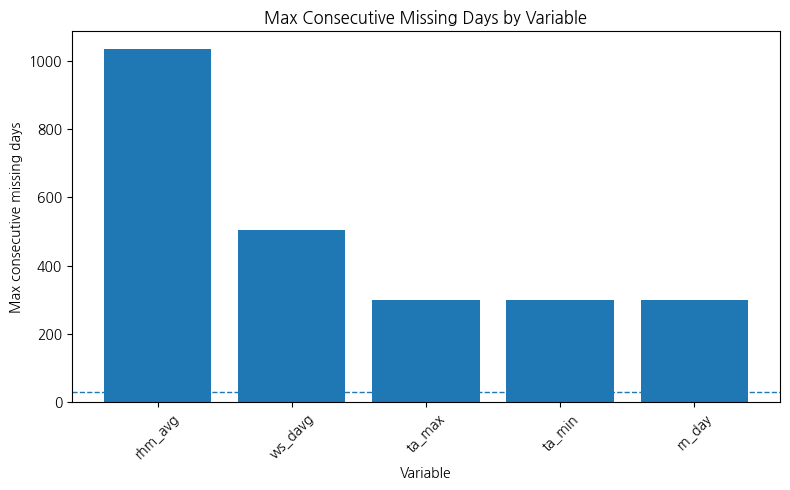

In [22]:
## 변수별 최대 연속 결측 길이 막대그래프
##
import matplotlib.pyplot as plt

plot_df = missing_summary.sort_values("max_consecutive_missing_days", ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(plot_df["variable"], plot_df["max_consecutive_missing_days"])
plt.axhline(30, linestyle="--", linewidth=1)
plt.title("Max Consecutive Missing Days by Variable")
plt.xlabel("Variable")
plt.ylabel("Max consecutive missing days")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

- 30일 이상이 존재하면 IDW 필요
- 300일 이상이면 단순 시간보간은 부적절

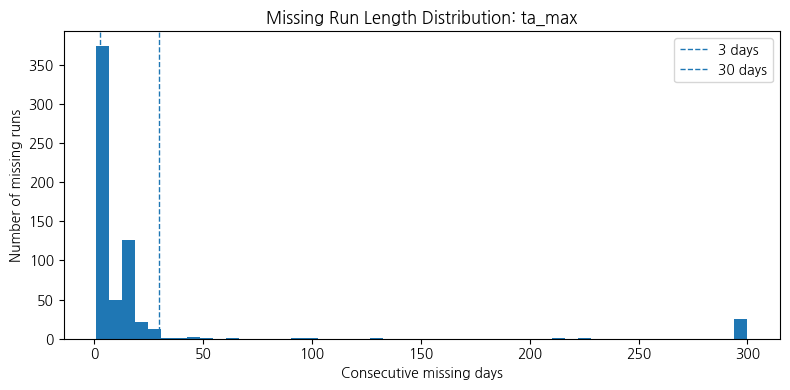

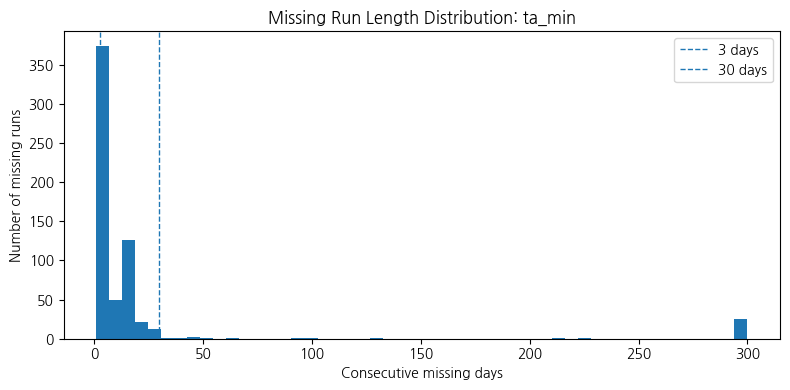

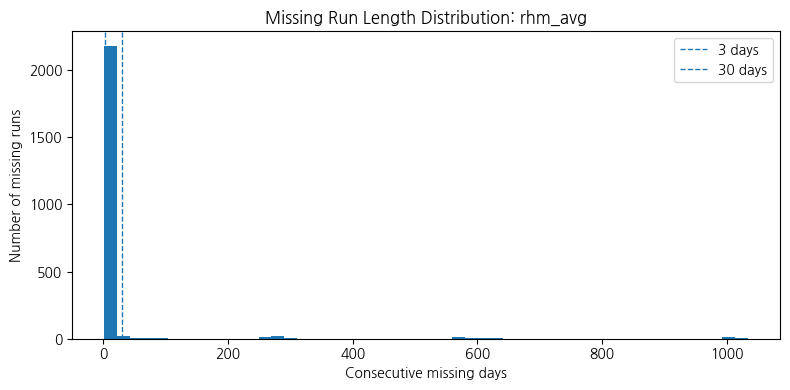

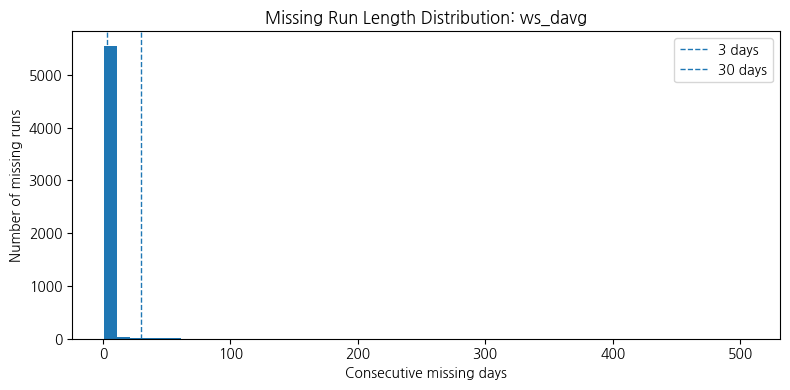

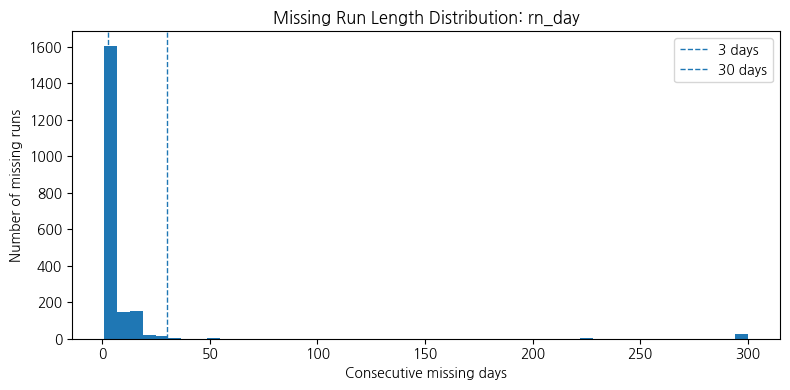

In [23]:
# 변수별 장기 결측 구간 길이 분포
for col in weather_cols:
    tmp = run_all[run_all["variable"] == col]

    if len(tmp) == 0:
        continue

    plt.figure(figsize=(8, 4))
    plt.hist(tmp["run_length"], bins=50)
    plt.axvline(3, linestyle="--", linewidth=1, label="3 days")
    plt.axvline(30, linestyle="--", linewidth=1, label="30 days")
    plt.title(f"Missing Run Length Distribution: {col}")
    plt.xlabel("Consecutive missing days")
    plt.ylabel("Number of missing runs")
    plt.legend()
    plt.tight_layout()
    plt.show()

| 패턴           | 해석           | 처리            |
| ------------ | ------------ | ------------- |
| 1~3일에 몰림     | 단기 누락        | 시간보간 적합       |
| 4~29일 많음     | 중기 결측        | 시간보간보다 IDW 적합 |
| 30일 이상 꼬리 존재 | 장기 관측 중단 가능  | IDW 필요        |
| 300일 이상 존재   | 관측소/센서 장기 문제 | 시간보간 금지       |


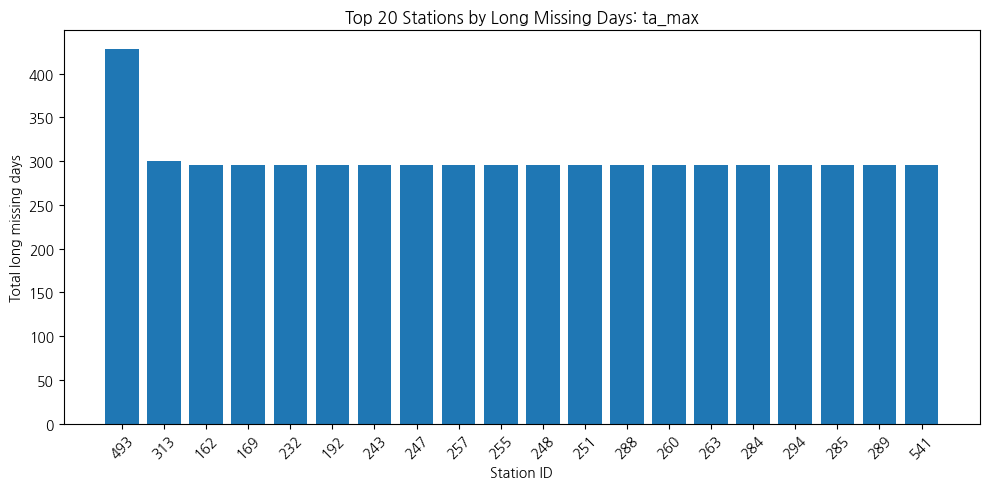

,stn,long_missing_days,max_run_length,num_long_runs
19,493,428,296,2
18,313,300,300,1
0,162,296,296,1
1,169,296,296,1
3,232,296,296,1
2,192,296,296,1
5,243,296,296,1
6,247,296,296,1
10,257,296,296,1
9,255,296,296,1


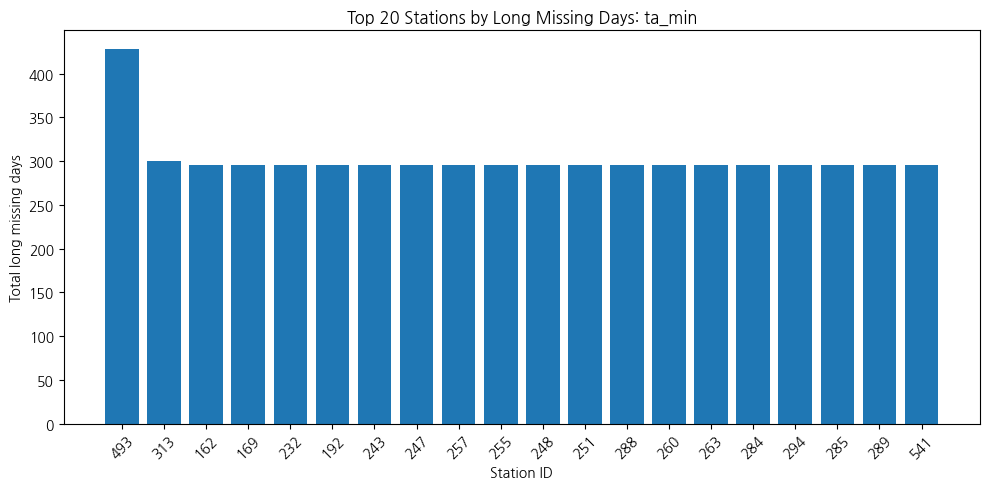

,stn,long_missing_days,max_run_length,num_long_runs
19,493,428,296,2
18,313,300,300,1
0,162,296,296,1
1,169,296,296,1
3,232,296,296,1
2,192,296,296,1
5,243,296,296,1
6,247,296,296,1
10,257,296,296,1
9,255,296,296,1


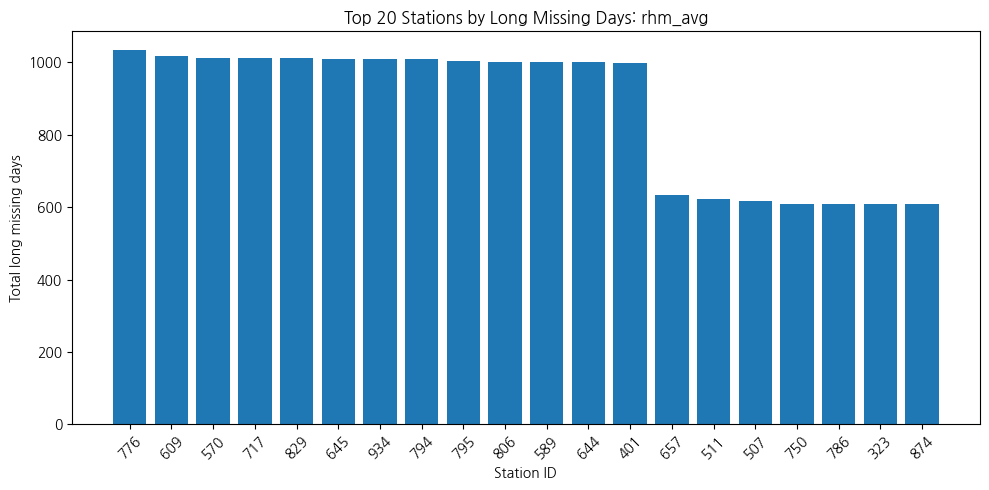

,stn,long_missing_days,max_run_length,num_long_runs
62,776,1034,1034,1
28,609,1017,1017,1
19,570,1011,1011,1
52,717,1011,1011,1
76,829,1011,1011,1
41,645,1010,1010,1
89,934,1010,1010,1
70,794,1009,1009,1
71,795,1004,1004,1
75,806,1001,1001,1


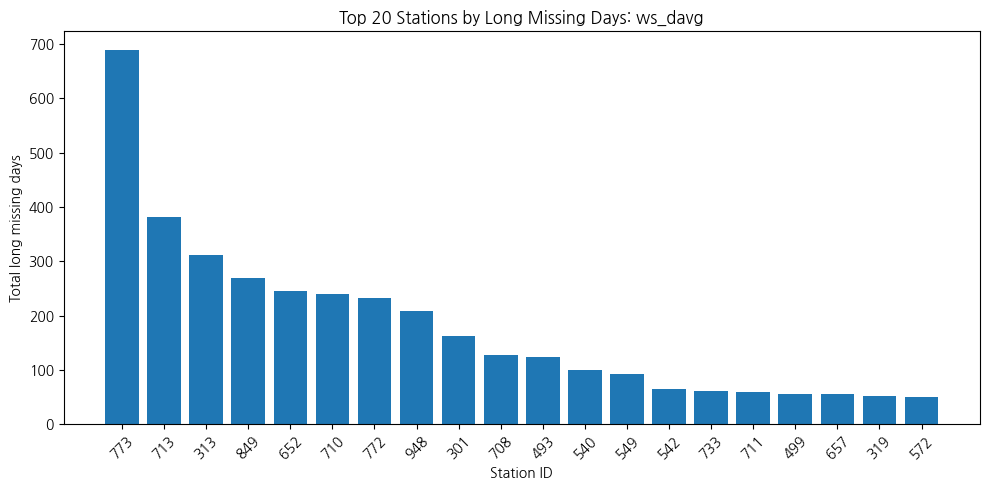

,stn,long_missing_days,max_run_length,num_long_runs
26,773,689,506,3
21,713,382,382,1
1,313,311,311,1
27,849,270,229,2
16,652,245,245,1
19,710,240,240,1
25,772,232,232,1
30,948,209,209,1
0,301,163,163,1
18,708,128,61,3


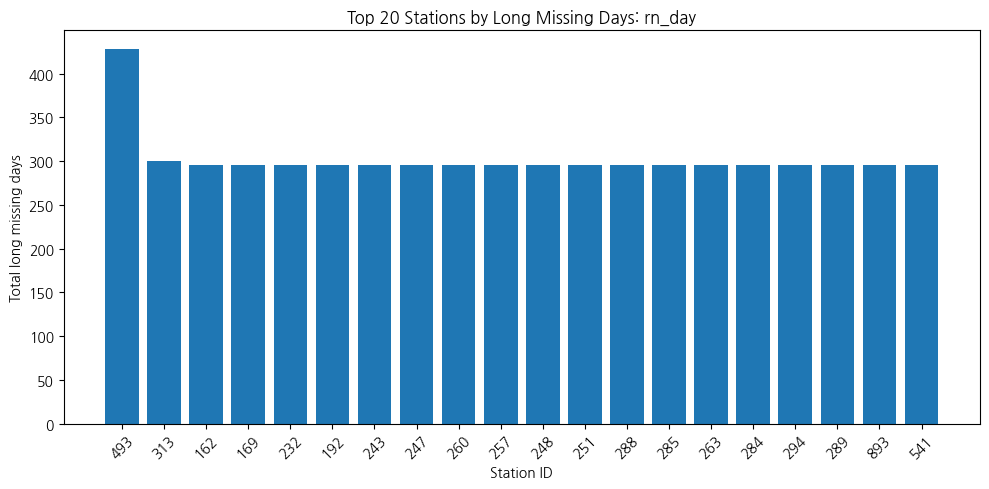

,stn,long_missing_days,max_run_length,num_long_runs
19,493,428,296,2
18,313,300,300,1
0,162,296,296,1
1,169,296,296,1
3,232,296,296,1
2,192,296,296,1
5,243,296,296,1
6,247,296,296,1
11,260,296,296,1
10,257,296,296,1


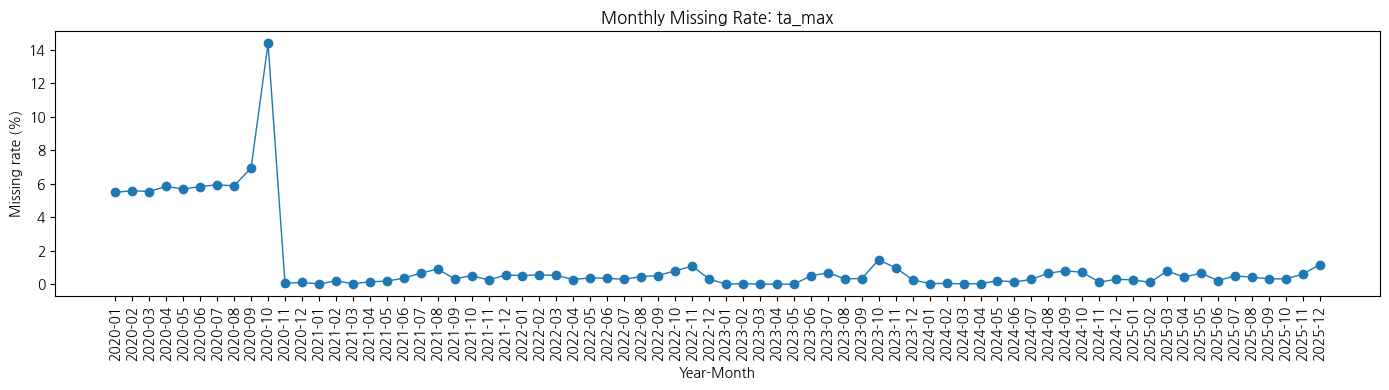

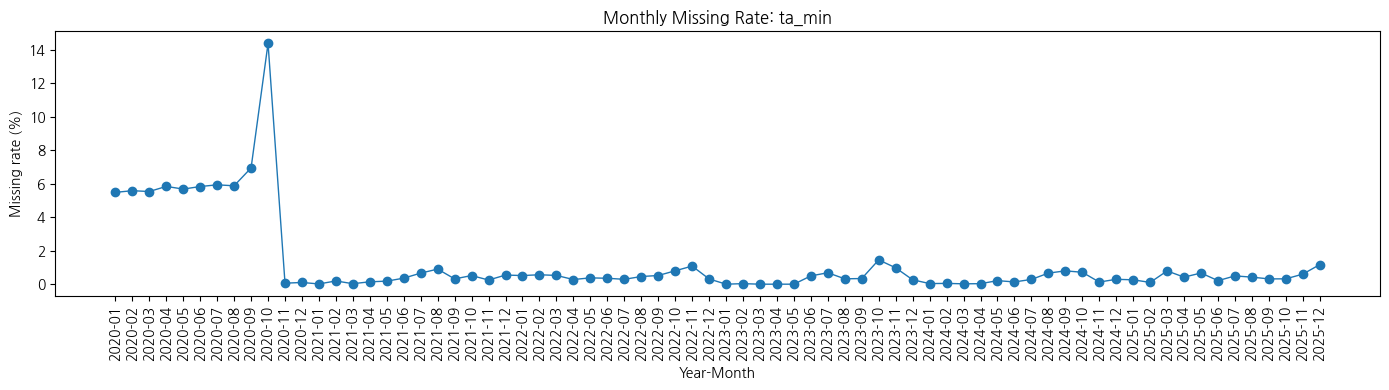

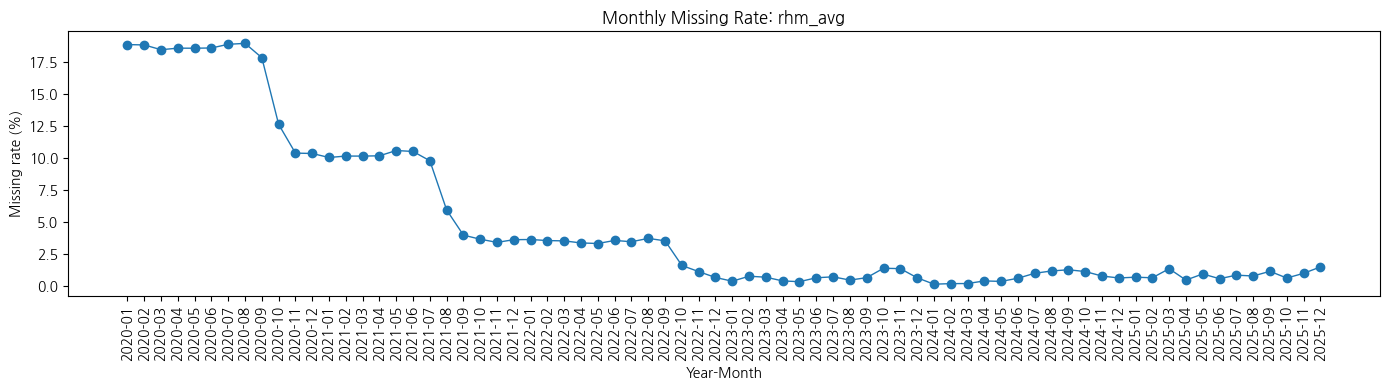

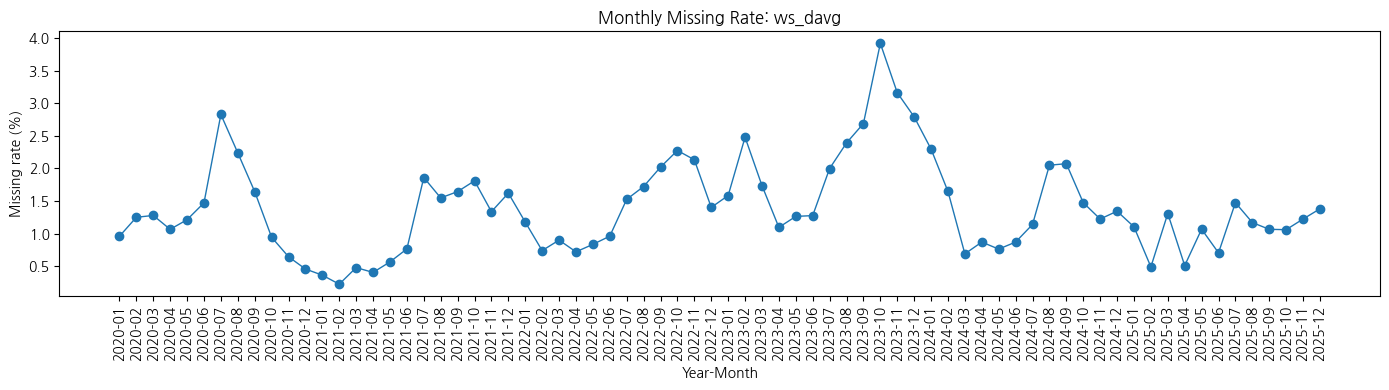

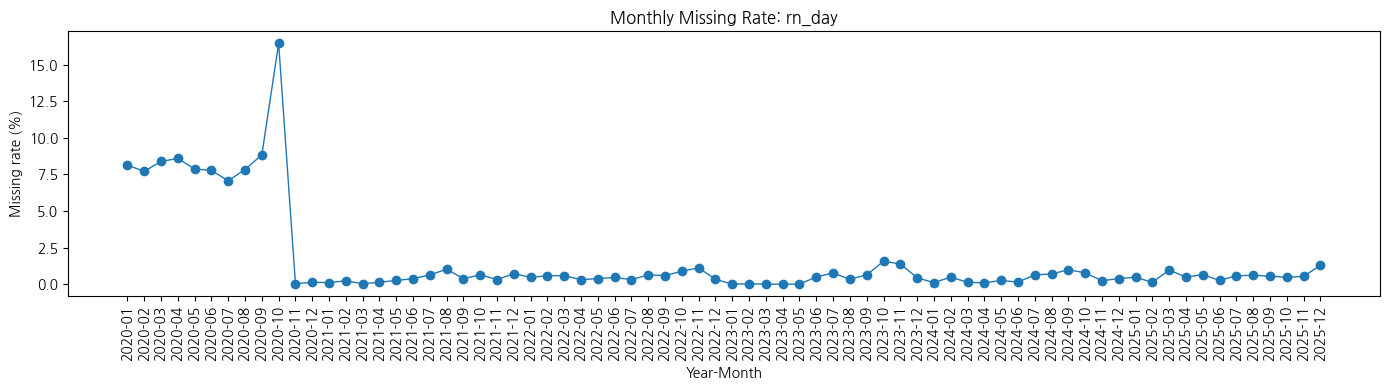

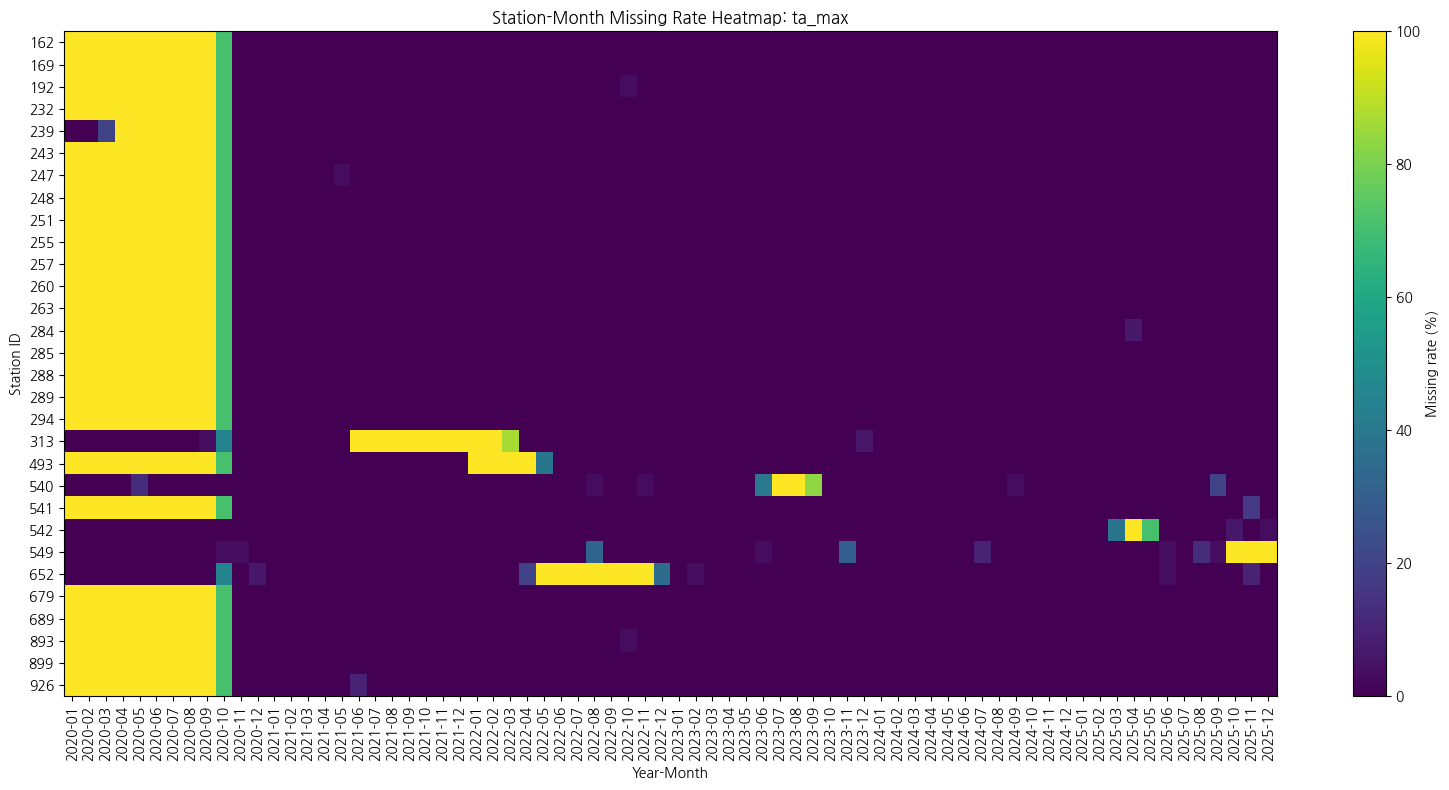

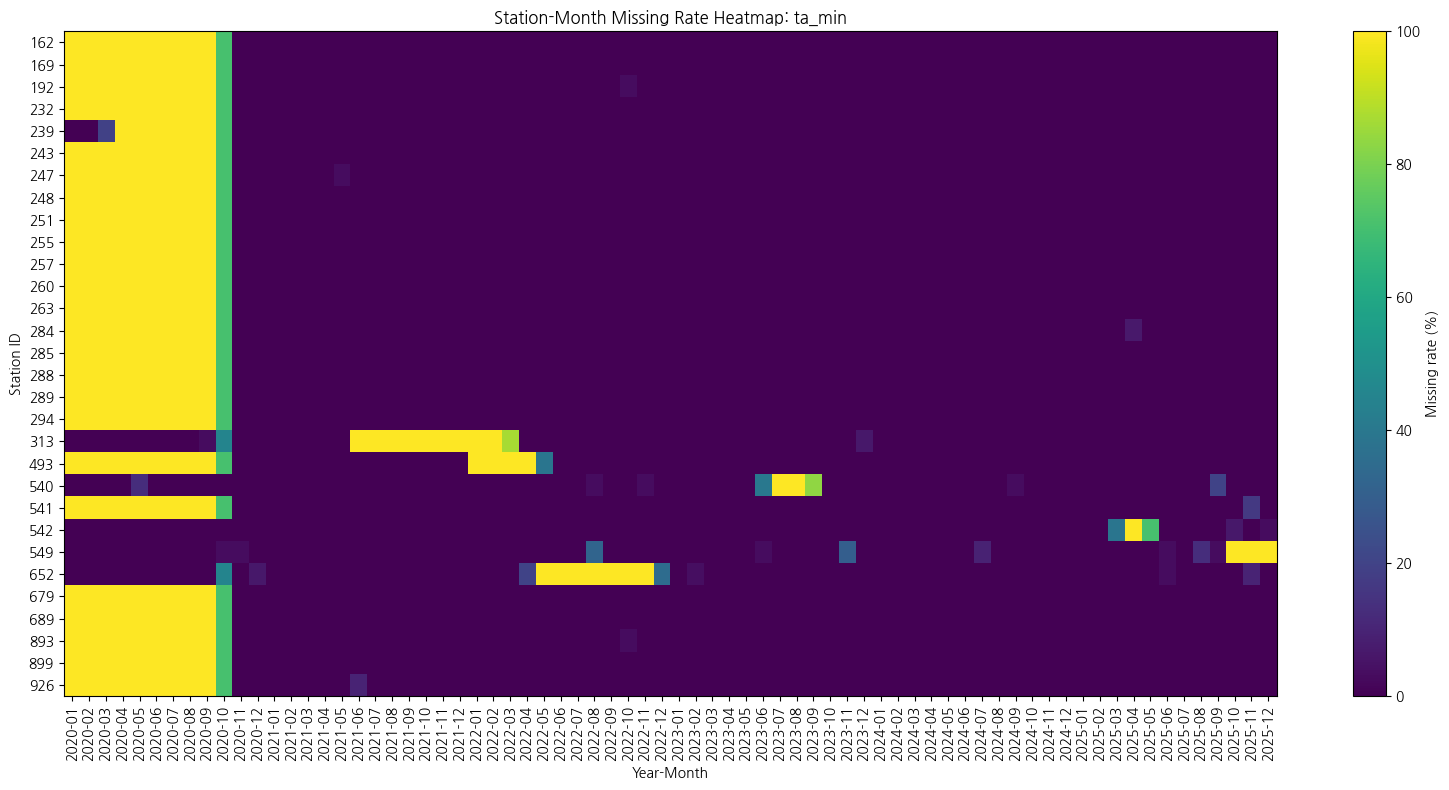

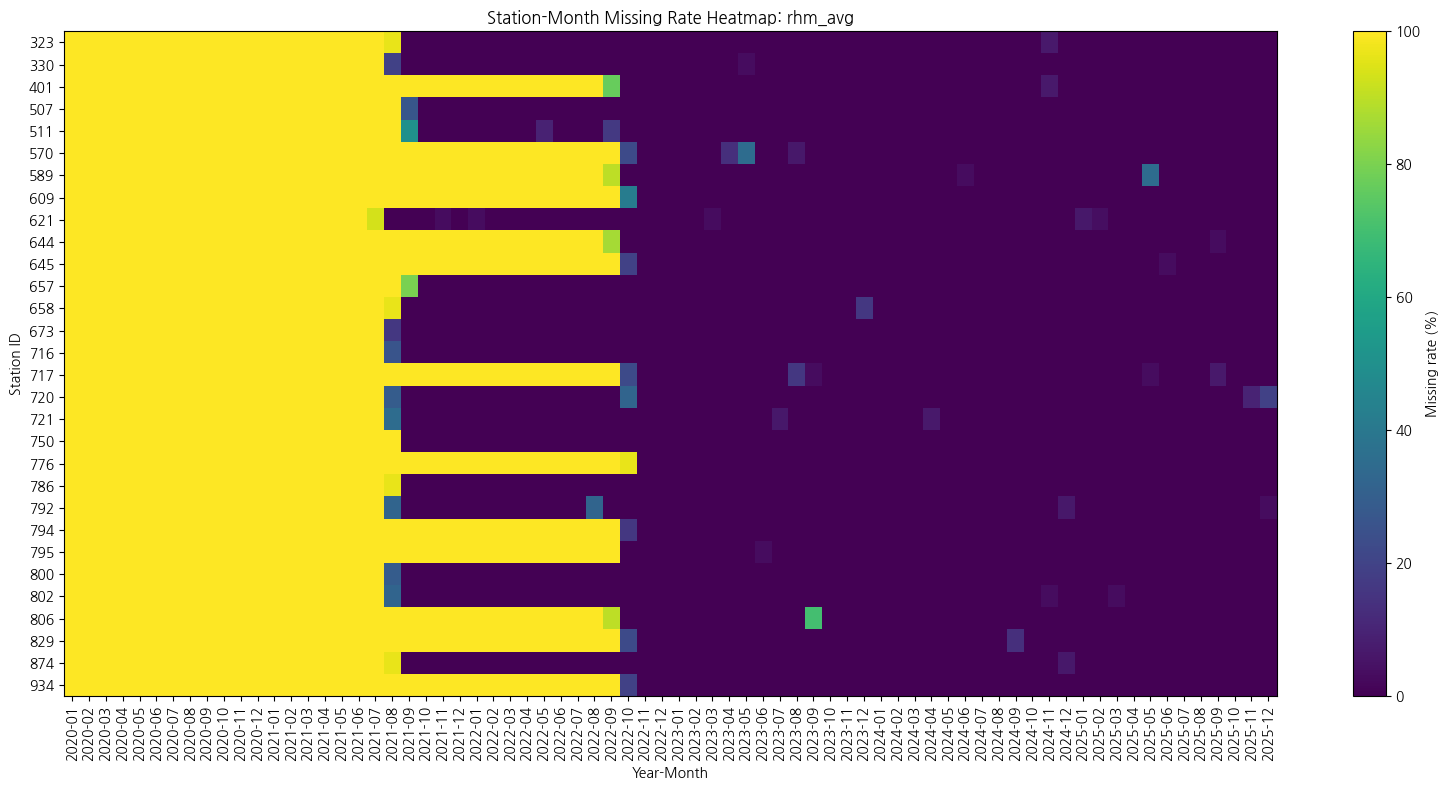

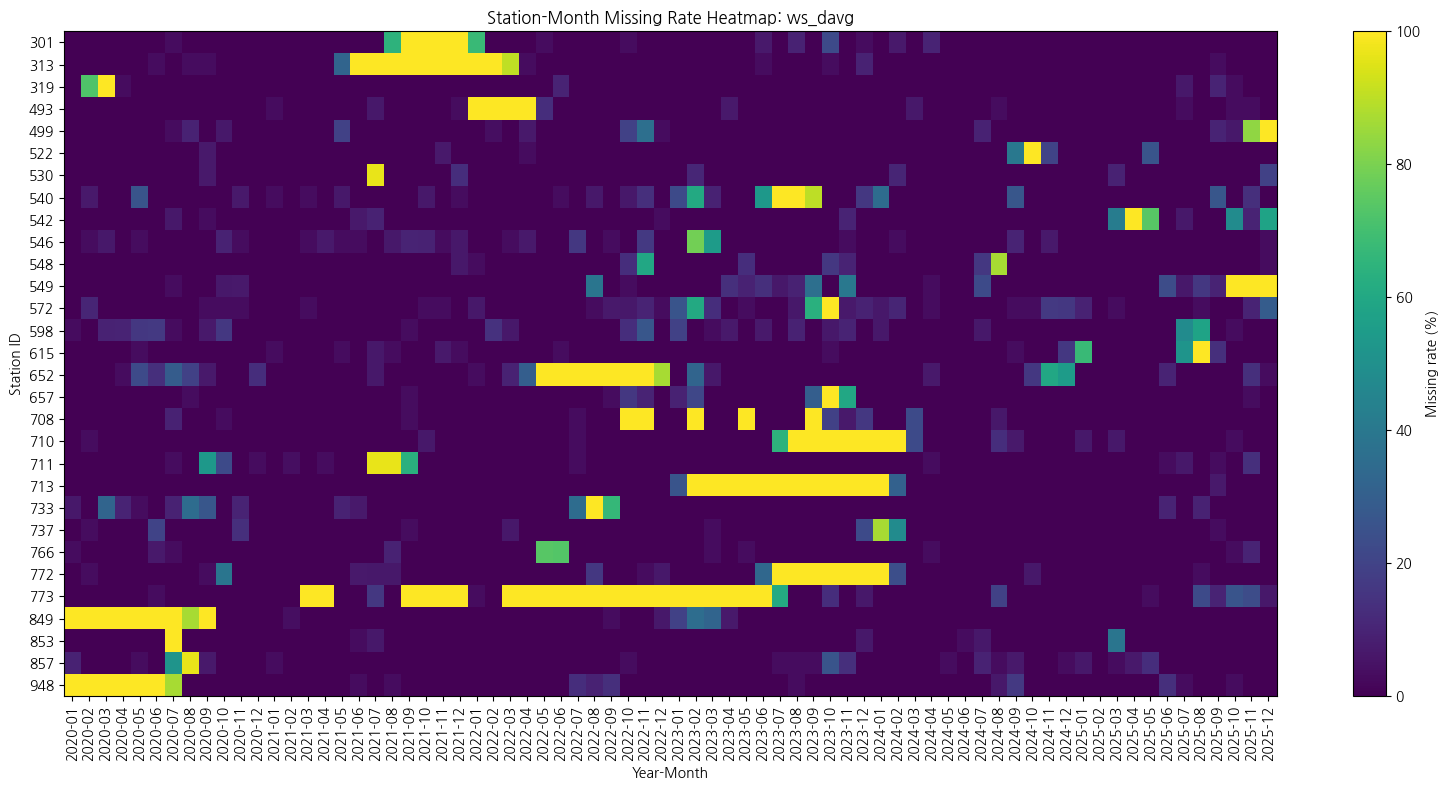

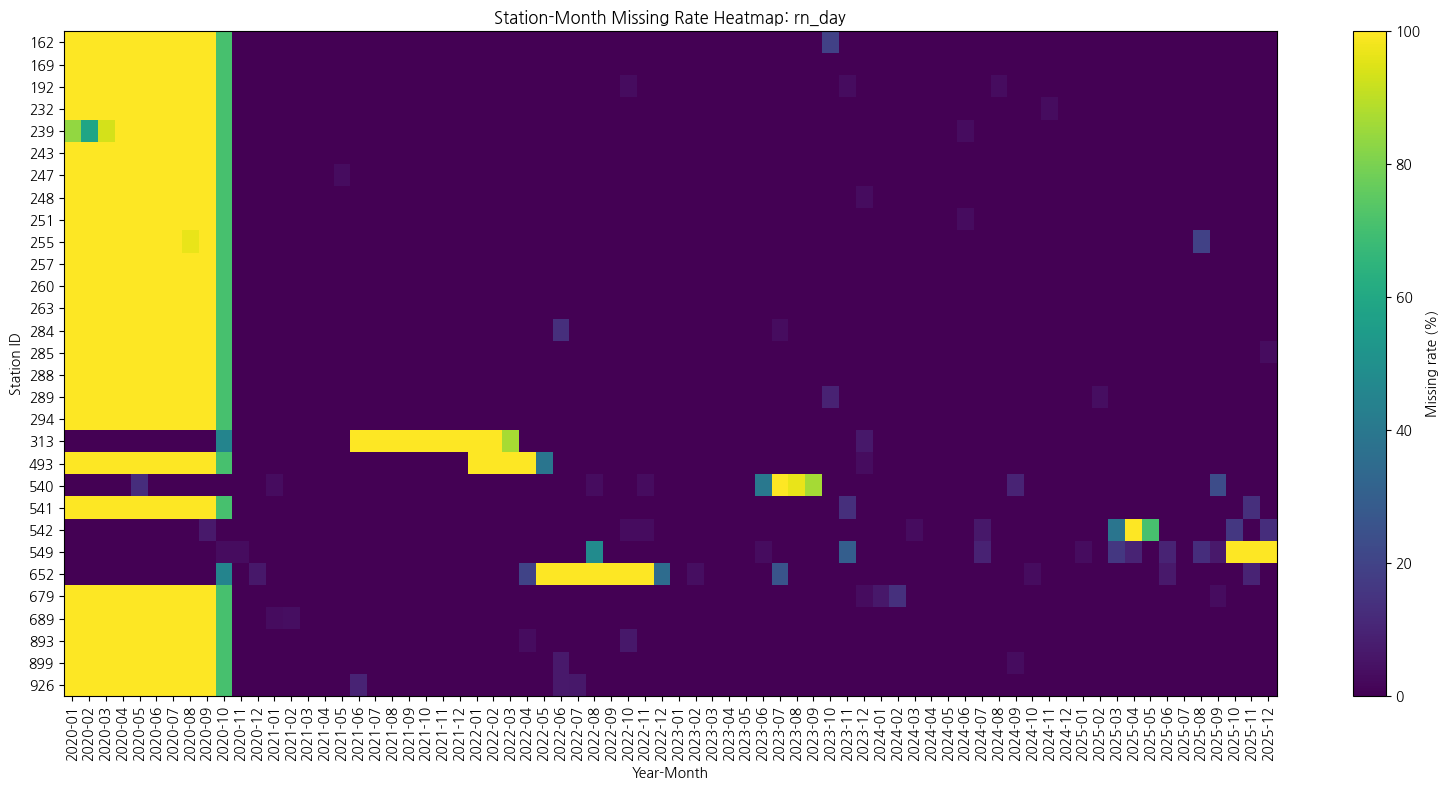

In [24]:
# 4. 관측소별 장기 결측 Top 20
long_runs = run_all[run_all["is_long_missing"]].copy()

for col in weather_cols:
    tmp = long_runs[long_runs["variable"] == col]

    if len(tmp) == 0:
        print(f"{col}: 30일 이상 장기 결측 없음")
        continue

    station_long = (
        tmp.groupby("stn", as_index=False)
        .agg(
            long_missing_days=("run_length", "sum"),
            max_run_length=("run_length", "max"),
            num_long_runs=("run_length", "count")
        )
        .sort_values("long_missing_days", ascending=False)
        .head(20)
    )

    plt.figure(figsize=(10, 5))
    plt.bar(station_long["stn"].astype(str), station_long["long_missing_days"])
    plt.title(f"Top 20 Stations by Long Missing Days: {col}")
    plt.xlabel("Station ID")
    plt.ylabel("Total long missing days")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    display(station_long)

# 월별 결측률 추이 - 어떤 특정 연도, 월에 몰렸는지 확인하기
df["year_month"] = df["date"].dt.to_period("M").astype(str)

monthly_missing = (
    df.groupby("year_month")[weather_cols]
    .apply(lambda x: x.isna().mean() * 100)
    .reset_index()
)

for col in weather_cols:
    plt.figure(figsize=(14, 4))
    plt.plot(monthly_missing["year_month"], monthly_missing[col], marker="o", linewidth=1)
    plt.title(f"Monthly Missing Rate: {col}")
    plt.xlabel("Year-Month")
    plt.ylabel("Missing rate (%)")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

# 관측소 × 월 결측률 heatmap : 어느 관측소가 어느 기간에 비어 있는지
for col in weather_cols:
    tmp_long = long_runs[long_runs["variable"] == col]

    if len(tmp_long) == 0:
        print(f"{col}: 장기 결측 없음")
        continue

    top_stn = (
        tmp_long.groupby("stn")["run_length"]
        .sum()
        .sort_values(ascending=False)
        .head(30)
        .index
    )

    heat_df = df[df["stn"].isin(top_stn)].copy()

    heat_table = (
        heat_df.groupby(["stn", "year_month"])[col]
        .apply(lambda x: x.isna().mean() * 100)
        .unstack("year_month")
        .fillna(0)
    )

    plt.figure(figsize=(16, 8))
    plt.imshow(heat_table, aspect="auto")
    plt.colorbar(label="Missing rate (%)")
    plt.title(f"Station-Month Missing Rate Heatmap: {col}")
    plt.xlabel("Year-Month")
    plt.ylabel("Station ID")
    plt.xticks(
        ticks=np.arange(len(heat_table.columns)),
        labels=heat_table.columns,
        rotation=90
    )
    plt.yticks(
        ticks=np.arange(len(heat_table.index)),
        labels=heat_table.index
    )
    plt.tight_layout()
    plt.show()

### 2-5. 최종 처리 방식



| 변수        | 최종 처리                                                                    |
| --------- | ------------------------------------------------------------------------ |
| `ta_max`  | 원결측 flag → 장기결측 flag → 3일 이하 시간보간 → IDW k=5 → 관측소-월 median → 전체 월 median |
| `ta_min`  | 원결측 flag → 장기결측 flag → 3일 이하 시간보간 → IDW k=5 → 관측소-월 median → 전체 월 median |
| `rhm_avg` | 원결측 flag → 장기결측 flag → 3일 이하 시간보간 → IDW k=5 → 관측소-월 median → 전체 월 median |
| `ws_davg` | 원결측 flag → 장기결측 flag → 3일 이하 시간보간 → IDW k=5 → 관측소-월 median → 전체 월 median |
| `rn_day`  | 원결측 flag → 장기결측 flag → 시간보간 없음 → IDW k=3 → 관측소-월 median → 전체 월 median    |


## [2] 결측치 처리

In [26]:
# 총 stn 갯숫
unique_stn = weather['stn'].unique()
print(f"Total number of unique station IDs: {len(unique_stn)}")

Total number of unique station IDs: 444


### 2-1. 공간적 데이터 보간을 위한 META Data matching


In [ ]:
'''
#============================================================
# 0. 입력 데이터 준비
# ============================================================
# weather: 기존 기상 데이터
# asos_meta: ASOS 메타 데이터
# aws_new: AWS 메타데이터

weather = pd.read_csv(r"C:\Users\user\OneDrive\바탕 화면\2026 날씨\주제2_축산\hanwoo\hanwoo_weather.csv")
aws_new = pd.read_csv(r"C:\Users\user\OneDrive\바탕 화면\2026 날씨\주제2_축산\hanwoo\aws_new.csv", encoding="cp949")
asos_meta = pd.read_csv(r"C:\Users\user\OneDrive\바탕 화면\2026 날씨\주제2_축산\hanwoo\asos_new.csv", encoding="cp949")

weather = weather.copy()
asos_meta = asos_meta.copy()
aws_new = aws_new.copy()

weather["stn"] = weather["stn"].astype(int)
weather["date"] = pd.to_datetime(weather["date"])

In [ ]:
'''
# ============================================================
# 1. 메타데이터 컬럼 자동 정리 함수
# ============================================================
def standardize_station_meta(meta, obs_type):
    meta = meta.copy()

    # 앞뒤 공백 제거
    meta.columns = meta.columns.astype(str).str.strip()

    # 가능한 컬럼명 후보
    col_candidates = {
        "stn": ["지점", "지점번호", "stn", "STN", "station_id", "station"],
        "stn_name": ["지점명", "관측소명", "stn_name", "STN_NAME", "station_name"],
        "lat": ["위도", "lat", "LAT", "latitude", "Latitude"],
        "lon": ["경도", "lon", "LON", "longitude", "Longitude"],
        "start_date": ["시작일", "시작일자", "관측시작일", "start_date", "START_DATE"],
        "end_date": ["종료일", "종료일자", "관측종료일", "end_date", "END_DATE"]
    }

    rename_dict = {}

    for std_col, candidates in col_candidates.items():
        for c in candidates:
            if c in meta.columns:
                rename_dict[c] = std_col
                break

    meta = meta.rename(columns=rename_dict)

    required_cols = ["stn", "lat", "lon"]
    missing_required = [c for c in required_cols if c not in meta.columns]

    if missing_required:
        raise ValueError(
            f"{obs_type} 메타데이터에서 필수 컬럼을 찾지 못했습니다: {missing_required}\n"
            f"현재 컬럼: {meta.columns.tolist()}"
        )

    if "stn_name" not in meta.columns:
        meta["stn_name"] = np.nan

    if "start_date" not in meta.columns:
        meta["start_date"] = pd.NaT

    if "end_date" not in meta.columns:
        meta["end_date"] = pd.NaT

    meta["obs_type"] = obs_type
    meta["stn"] = meta["stn"].astype(int)

    meta["lat"] = pd.to_numeric(meta["lat"], errors="coerce")
    meta["lon"] = pd.to_numeric(meta["lon"], errors="coerce")

    meta["start_date"] = pd.to_datetime(meta["start_date"], errors="coerce")
    meta["end_date"] = pd.to_datetime(meta["end_date"], errors="coerce")

    # 종료일 결측은 운영 중으로 처리
    meta["end_date"] = meta["end_date"].fillna(pd.Timestamp("2099-12-31"))

    meta = meta[
        ["obs_type", "stn", "stn_name", "lat", "lon", "start_date", "end_date"]
    ].copy()

    # 좌표 없는 메타는 IDW에 사용할 수 없으므로 제거하지는 않고 확인용으로 유지
    return meta


asos_meta_std = standardize_station_meta(asos_meta, "ASOS")
aws_meta_std = standardize_station_meta(aws_new, "AWS")


# ============================================================
# 2. 메타데이터 자체 점검
# ============================================================
print("========== [Meta station count] ==========")
print("ASOS meta unique stn:", asos_meta_std["stn"].nunique())
print("AWS  meta unique stn:", aws_meta_std["stn"].nunique())
print("Weather unique stn  :", weather["stn"].nunique())

print("\n========== [Meta coordinate missing] ==========")
print("ASOS lat/lon missing rows:")
print(asos_meta_std[["lat", "lon"]].isna().sum())

print("\nAWS lat/lon missing rows:")
print(aws_meta_std[["lat", "lon"]].isna().sum())


# ============================================================
# 3. weather의 stn이 ASOS/AWS 중 어디에 속하는지 재분류
# ============================================================
weather_stn = pd.DataFrame({
    "stn": sorted(weather["stn"].dropna().astype(int).unique())
})

asos_stn = set(asos_meta_std.loc[asos_meta_std["lat"].notna() & asos_meta_std["lon"].notna(), "stn"])
aws_stn = set(aws_meta_std.loc[aws_meta_std["lat"].notna() & aws_meta_std["lon"].notna(), "stn"])

weather_stn["in_asos"] = weather_stn["stn"].isin(asos_stn)
weather_stn["in_aws"] = weather_stn["stn"].isin(aws_stn)

def classify_station(row):
    if row["in_asos"] and row["in_aws"]:
        return "BOTH"
    elif row["in_asos"]:
        return "ASOS"
    elif row["in_aws"]:
        return "AWS"
    else:
        return "UNKNOWN"

weather_stn["obs_type_check"] = weather_stn.apply(classify_station, axis=1)

print("\n========== [Weather stn classification] ==========")
print(weather_stn["obs_type_check"].value_counts())


# ============================================================
# 4. 중복/이력 메타 처리
#    - 같은 obs_type, stn에 여러 좌표 이력이 있으면
#      weather 기간과 겹치는 이력 중 가장 최근 start_date 사용
# ============================================================
station_meta = pd.concat([asos_meta_std, aws_meta_std], ignore_index=True)

weather_start = weather["date"].min()
weather_end = weather["date"].max()

station_meta["overlap_weather_period"] = (
    station_meta["start_date"].fillna(pd.Timestamp("1900-01-01")).le(weather_end)
    &
    station_meta["end_date"].fillna(pd.Timestamp("2099-12-31")).ge(weather_start)
)

# weather 기간과 겹치는 이력을 우선, 그 안에서 start_date가 최신인 것을 우선
station_meta_best = (
    station_meta
    .sort_values(
        by=["obs_type", "stn", "overlap_weather_period", "start_date"],
        ascending=[True, True, False, False]
    )
    .drop_duplicates(["obs_type", "stn"], keep="first")
    .copy()
)

station_meta_best = station_meta_best[
    ["obs_type", "stn", "stn_name", "lat", "lon", "start_date", "end_date"]
]


# ============================================================
# 5. weather에 obs_type 붙이기
# ============================================================
weather_with_type = weather.merge(
    weather_stn[["stn", "obs_type_check"]],
    on="stn",
    how="left"
)

weather_with_type = weather_with_type.rename(columns={"obs_type_check": "obs_type"})


# ============================================================
# 6. BOTH 처리
#    - BOTH가 있으면 stn만으로 ASOS/AWS를 확정할 수 없음
#    - 일단 merge에서 제외되도록 NaN 처리
# ============================================================
both_stn = weather_stn.loc[weather_stn["obs_type_check"] == "BOTH", "stn"].tolist()

if len(both_stn) > 0:
    print("\n[주의] ASOS/AWS 양쪽에 모두 존재하는 stn이 있습니다.")
    print("BOTH stn:", both_stn[:50])
    print("이 지점은 원본 파일 출처 기준으로 ASOS/AWS를 확정해야 합니다.")
    weather_with_type.loc[weather_with_type["obs_type"] == "BOTH", "obs_type"] = np.nan


# ============================================================
# 7. weather + station_meta merge
# ============================================================
weather_merged = weather_with_type.merge(
    station_meta_best,
    on=["obs_type", "stn"],
    how="left"
)


# ============================================================
# 8. 매칭 결과 점검
# ============================================================
print("\n========== [Final matching check: station-level] ==========")

station_check = (
    weather_merged
    .groupby("stn", as_index=False)
    .agg(
        obs_type=("obs_type", "first"),
        lat=("lat", "first"),
        lon=("lon", "first"),
        stn_name=("stn_name", "first")
    )
)

station_check["coord_matched"] = station_check["lat"].notna() & station_check["lon"].notna()

print("전체 weather 관측소 수:", station_check["stn"].nunique())
print("좌표 매칭 관측소 수:", station_check["coord_matched"].sum())
print("좌표 미매칭 관측소 수:", (~station_check["coord_matched"]).sum())

print("\n관측소 기준 좌표 매칭률:")
print(round(station_check["coord_matched"].mean() * 100, 2), "%")

print("\nobs_type 분포:")
print(station_check["obs_type"].value_counts(dropna=False))


print("\n========== [Final matching check: row-level] ==========")
row_coord_matched = weather_merged["lat"].notna() & weather_merged["lon"].notna()

print("전체 weather 행 수:", len(weather_merged))
print("좌표 매칭 행 수:", row_coord_matched.sum())
print("좌표 미매칭 행 수:", (~row_coord_matched).sum())

print("\n행 기준 좌표 매칭률:")
print(round(row_coord_matched.mean() * 100, 2), "%")


# ============================================================
# 9. 미매칭 관측소 확인
# ============================================================
unmatched_station = station_check.loc[
    ~station_check["coord_matched"],
    ["stn", "obs_type", "stn_name", "lat", "lon"]
].sort_values("stn")

print("\n========== [Unmatched station list] ==========")
print("미매칭 관측소 수:", len(unmatched_station))
display(unmatched_station.head(100))


# ============================================================
# 10. 번호대별 미매칭 확인
# ============================================================
if len(unmatched_station) > 0:
    unmatched_station = unmatched_station.copy()
    unmatched_station["stn_bin"] = pd.cut(
        unmatched_station["stn"],
        bins=[0, 199, 399, 599, 799, 999, 9999],
        labels=["0-199", "200-399", "400-599", "600-799", "800-999", "1000+"]
    )

    print("\n========== [Unmatched station by stn range] ==========")
    display(unmatched_station["stn_bin"].value_counts().sort_index())

print("\n완료: weather_merged 생성됨")
print(weather_merged.columns.tolist())
display(weather_merged.head())

In [ ]:
# weather_merged 데이터 따로 저장

###2-2 IDW 보간

In [27]:
import pandas as pd
weather_merged = pd.read_csv("/content/drive/MyDrive/2026_기상청_축산/weather_with_station_coord.csv")

In [24]:
weather_merged.head()

,stn,date,ta_max,rn_day,ta_min,rhm_avg,ws_davg,obs_type,stn_name,lat,lon,start_date,end_date
0,95,2020-01-01,0.7,0.0,-9.0,78.4,0.7,ASOS,철원,38.1479,127.3042,1988-01-01,2099-12-31
1,95,2020-01-02,2.1,0.0,-4.7,87.8,0.7,ASOS,철원,38.1479,127.3042,1988-01-01,2099-12-31
2,95,2020-01-03,3.3,0.0,-8.4,82.0,0.6,ASOS,철원,38.1479,127.3042,1988-01-01,2099-12-31
3,95,2020-01-04,5.2,0.0,-9.7,79.3,0.6,ASOS,철원,38.1479,127.3042,1988-01-01,2099-12-31
4,95,2020-01-05,5.3,0.0,-10.4,78.3,0.5,ASOS,철원,38.1479,127.3042,1988-01-01,2099-12-31


In [28]:
################
# 결측치 표준화 - -99, -99.0을 NaN으로 표준화
################

def replace_minus99_to_nan(df):
    df = weather_merged.copy()

    for col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            df[col] = df[col].mask(df[col].isin([-99, -99.0]), np.nan)
        else:
            df[col] = (
                df[col]
                .astype("string")
                .str.strip()
                .replace(r"^-99(\.0+)?$", np.nan, regex=True)
            )

    return df


weather_merged = replace_minus99_to_nan(weather_merged)

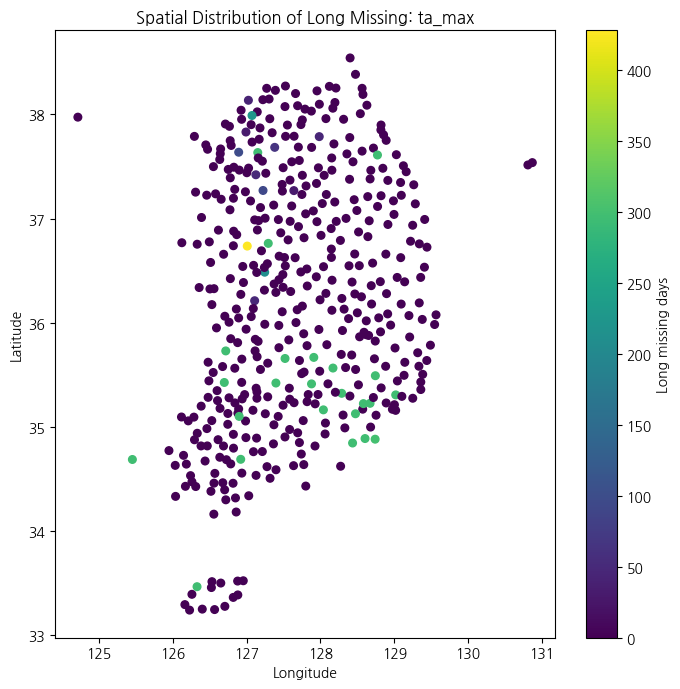

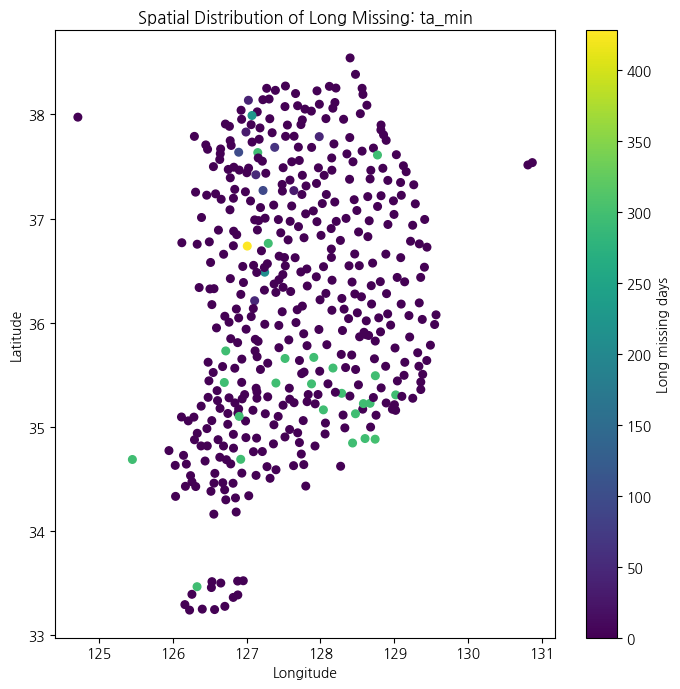

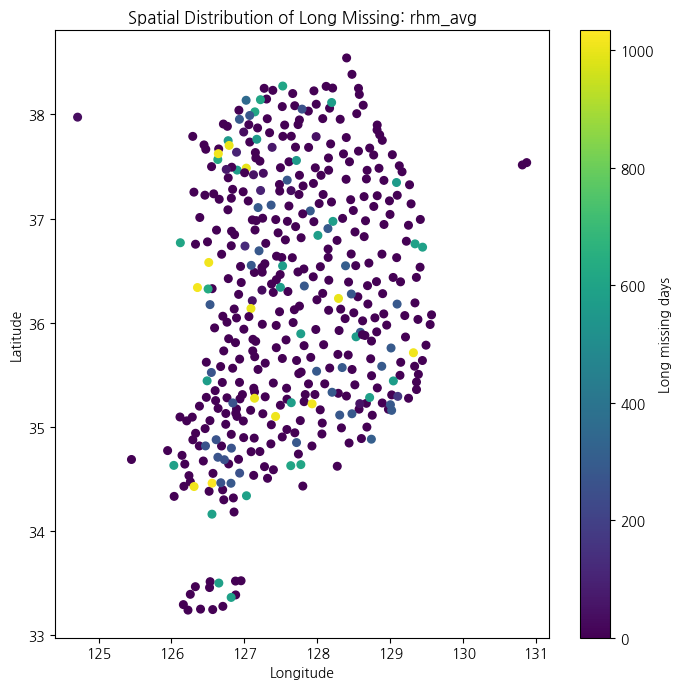

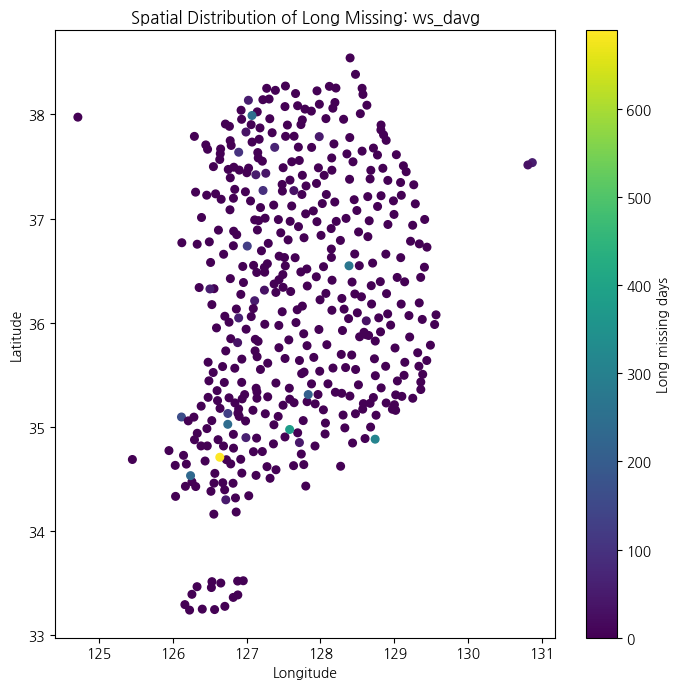

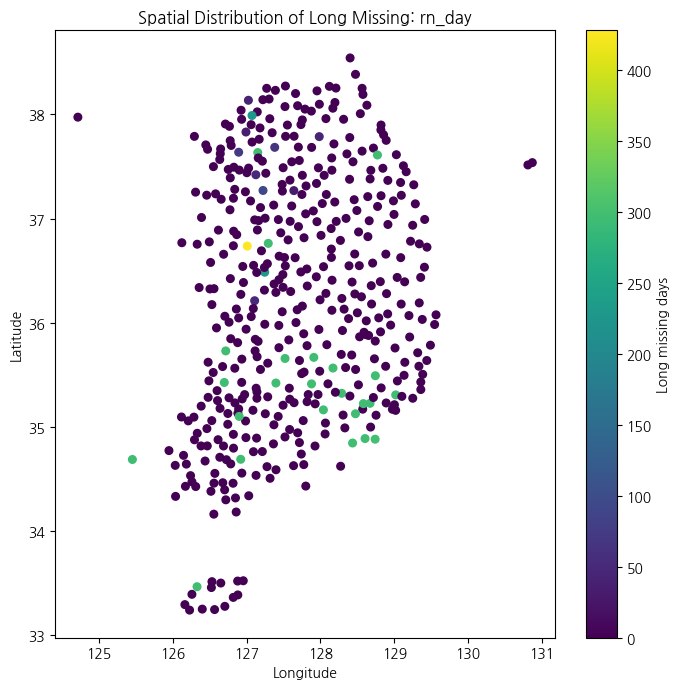

In [29]:
## 장기 결측 관측소 위치 확인
# 결측 관측소가 특정 지역에 몰려 있으면, 주변 관측소도 비슷하게 별측일 수 있으므로, 그러면 IDW 품질이 떨어질 수 있다

long_runs = run_all[run_all["is_long_missing"]].copy()

station_coord = (
    weather_merged[["stn", "lat", "lon", "obs_type"]]
    .drop_duplicates("stn")
    .copy()
)

for col in weather_cols:
    tmp = long_runs[long_runs["variable"] == col]

    if len(tmp) == 0:
        print(f"{col}: 장기 결측 없음")
        continue

    station_long = (
        tmp.groupby("stn", as_index=False)
        .agg(long_missing_days=("run_length", "sum"))
    )

    plot_df = station_coord.merge(station_long, on="stn", how="left")
    plot_df["long_missing_days"] = plot_df["long_missing_days"].fillna(0)

    plt.figure(figsize=(7, 7))
    sc = plt.scatter(
        plot_df["lon"],
        plot_df["lat"],
        c=plot_df["long_missing_days"],
        s=30
    )
    plt.colorbar(sc, label="Long missing days")
    plt.title(f"Spatial Distribution of Long Missing: {col}")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.tight_layout()
    plt.show()

확인해본 결과...

| 변수        | 공간적 몰림 정도 | 판단                     |
| --------- | --------: | ---------------------- |
| `ta_max`  |     낮음~보통 | IDW 적용 괜찮음             |
| `ta_min`  |     낮음~보통 | IDW 적용 괜찮음             |
| `rhm_avg` |     보통~높음 | IDW 필요하지만 보간 후 검증 필수   |
| `ws_davg` |        낮음 | IDW 적용 괜찮음             |
| `rn_day`  |     낮음~보통 | IDW 적용 괜찮음, 시간보간 제외 유지 |


In [30]:
# ============================================================
# IDW 가능성 점검:
# 결측 row마다 같은 날짜에 관측값이 존재하는 관측소 수 확인
# ============================================================

weather_cols = ["ta_max", "ta_min", "rhm_avg", "ws_davg", "rn_day"]

for col in weather_cols:
    tmp = weather_merged.copy()

    date_available_count = (
        tmp.groupby("date")[col]
        .apply(lambda x: x.notna().sum())
        .rename("available_station_count")
        .reset_index()
    )

    miss_dates = (
        tmp.loc[tmp[col].isna(), ["date"]]
        .merge(date_available_count, on="date", how="left")
    )

    print(f"\n[{col}]")
    print("결측 row 수:", len(miss_dates))

    if len(miss_dates) > 0:
        print(miss_dates["available_station_count"].describe())
        print("같은 날짜 사용 가능 관측소 5개 미만 row 수:",
              (miss_dates["available_station_count"] < 5).sum())
        print("같은 날짜 사용 가능 관측소 3개 미만 row 수:",
              (miss_dates["available_station_count"] < 3).sum())


[ta_max]
결측 row 수: 12364
count    12364.000000
mean       409.785668
std         38.118775
min        316.000000
25%        417.000000
50%        419.000000
75%        436.000000
max        443.000000
Name: available_station_count, dtype: float64
같은 날짜 사용 가능 관측소 5개 미만 row 수: 0
같은 날짜 사용 가능 관측소 3개 미만 row 수: 0

[ta_min]
결측 row 수: 12364
count    12364.000000
mean       409.785668
std         38.118775
min        316.000000
25%        417.000000
50%        419.000000
75%        436.000000
max        443.000000
Name: available_station_count, dtype: float64
같은 날짜 사용 가능 관측소 5개 미만 row 수: 0
같은 날짜 사용 가능 관측소 3개 미만 row 수: 0

[rhm_avg]
결측 row 수: 48155
count    48155.000000
mean       388.132427
std         28.677148
min        353.000000
25%        361.000000
50%        394.000000
75%        400.000000
max        443.000000
Name: available_station_count, dtype: float64
같은 날짜 사용 가능 관측소 5개 미만 row 수: 0
같은 날짜 사용 가능 관측소 3개 미만 row 수: 0

[ws_davg]
결측 row 수: 13602
count    13602.000000
mean       434.94118

| 변수        | 결측 row 수 | 결측 날짜에 사용 가능한 관측소 수 최소값 | IDW 가능 여부 |
| --------- | -------: | ----------------------: | --------- |
| `ta_max`  |   12,364 |                    316개 | 가능        |
| `ta_min`  |   12,364 |                    316개 | 가능        |
| `rhm_avg` |   48,155 |                    353개 | 가능        |
| `ws_davg` |   13,602 |                    407개 | 가능        |
| `rn_day`  |   15,993 |                    300개 | 가능        |

- 현재 가정에서
-----
같은 날짜 사용 가능 관측소 5개 미만 row 수: 0
같은 날짜 사용 가능 관측소 3개 미만 row 수: 0
-----

이므로,어떤 결측 row도 IDW 후보 관측소 부족 문제는 없다.

In [32]:
# ============================================================
# 기상 데이터 최종 결측치 보간 코드
# - 짧은 결측: 관측소별 3일 이하 시간보간
# - 장기/잔여 결측: 같은 날짜 주변 관측소 IDW
# - fallback: 관측소-월 median → 전체 월 median
# ============================================================

import pandas as pd
import numpy as np

# ============================================================
# 0. 기본 준비: 불필요 컬럼 제거
# ============================================================

weather_imp = weather_merged.copy()

# IDW에 lat/lon은 필요하므로 제거하지 않음
drop_cols = ["stn_name", "start_date", "end_date"]
weather_imp = weather_imp.drop(columns=[c for c in drop_cols if c in weather_imp.columns])

# 필수 컬럼 확인
required_cols = [
    "stn", "date", "lat", "lon",
    "ta_max", "ta_min", "rhm_avg", "ws_davg", "rn_day"
]

missing_cols = [c for c in required_cols if c not in weather_imp.columns]

if missing_cols:
    raise ValueError(f"필수 컬럼이 없습니다: {missing_cols}")

# 타입 정리
weather_imp["stn"] = weather_imp["stn"].astype(int)
weather_imp["date"] = pd.to_datetime(weather_imp["date"])
weather_imp["lat"] = pd.to_numeric(weather_imp["lat"], errors="coerce")
weather_imp["lon"] = pd.to_numeric(weather_imp["lon"], errors="coerce")

# 좌표 결측 확인
if weather_imp[["lat", "lon"]].isna().sum().sum() > 0:
    raise ValueError("lat/lon 결측이 존재합니다. IDW 전에 관측소 좌표 매칭을 다시 확인하세요.")

weather_imp = weather_imp.sort_values(["stn", "date"]).reset_index(drop=True)

weather_cols = ["ta_max", "ta_min", "rhm_avg", "ws_davg", "rn_day"]
time_interp_cols = ["ta_max", "ta_min", "rhm_avg", "ws_davg"]

LONG_MISSING_DAYS = 30
SHORT_GAP_DAYS = 3


# ============================================================
# 1. 원래 결측 flag + 장기 결측 flag 생성
# ============================================================

def make_long_missing_flag(s, threshold=30):
    """
    관측소별 연속 결측 길이를 계산하고,
    threshold일 이상 연속 결측이면 1로 표시.
    """
    mask = s.isna()
    run_id = (mask != mask.shift()).cumsum()
    run_len = mask.groupby(run_id).transform("sum")

    return (mask & (run_len >= threshold)).astype(int)


for col in weather_cols:
    weather_imp[f"{col}_raw"] = weather_imp[col]
    weather_imp[f"{col}_missing"] = weather_imp[col].isna().astype(int)

    weather_imp[f"{col}_long_missing"] = (
        weather_imp
        .groupby("stn")[col]
        .transform(lambda x: make_long_missing_flag(x, LONG_MISSING_DAYS))
        .astype(int)
    )

    weather_imp[f"{col}_impute_method"] = np.where(
        weather_imp[col].isna(),
        "missing_pending",
        "observed"
    )


# ============================================================
# 2. 3일 이하 short gap만 관측소별 시간보간
#    - rn_day는 강수량이므로 시간보간하지 않음
# ============================================================

def fill_short_gap_only(s, max_gap=3):
    """
    연속 결측 길이가 max_gap 이하인 구간만 선형보간.
    긴 결측은 그대로 NaN 유지.
    """
    mask = s.isna()
    run_id = (mask != mask.shift()).cumsum()
    run_len = mask.groupby(run_id).transform("sum")

    short_gap_mask = mask & (run_len <= max_gap)

    interpolated = s.interpolate(
        method="linear",
        limit_area="inside"
    )

    out = s.copy()
    out.loc[short_gap_mask] = interpolated.loc[short_gap_mask]

    return out


for col in time_interp_cols:
    before = weather_imp[col].copy()

    weather_imp[col] = (
        weather_imp
        .groupby("stn", group_keys=False)[col]
        .apply(lambda x: fill_short_gap_only(x, SHORT_GAP_DAYS))
    )

    filled_mask = before.isna() & weather_imp[col].notna()
    weather_imp.loc[filled_mask, f"{col}_impute_method"] = "time_interp_3d"

    print(f"[Time interpolation] {col}: {before.isna().sum()} -> {weather_imp[col].isna().sum()}")

print("[Time interpolation] rn_day: skipped")


# ============================================================
# 3. 관측소 간 거리 행렬 생성
#    - Haversine distance 사용
# ============================================================

station_coord = (
    weather_imp[["stn", "lat", "lon"]]
    .drop_duplicates("stn")
    .sort_values("stn")
    .reset_index(drop=True)
)

station_ids = station_coord["stn"].values
stn_to_idx = {stn: i for i, stn in enumerate(station_ids)}

lat_rad = np.radians(station_coord["lat"].values)
lon_rad = np.radians(station_coord["lon"].values)

R = 6371.0  # 지구 반지름, km

dlat = lat_rad[:, None] - lat_rad[None, :]
dlon = lon_rad[:, None] - lon_rad[None, :]

a = (
    np.sin(dlat / 2) ** 2
    + np.cos(lat_rad[:, None])
    * np.cos(lat_rad[None, :])
    * np.sin(dlon / 2) ** 2
)

dist_matrix = 2 * R * np.arcsin(np.sqrt(a))

# 자기 자신은 IDW 후보에서 제외
np.fill_diagonal(dist_matrix, np.inf)


# ============================================================
# 4. 같은 날짜 기준 IDW 공간보간 함수
# ============================================================

def idw_fill_by_date(data, col, k=5, power=2):
    """
    같은 날짜에 관측값이 존재하는 주변 관측소 중
    가까운 k개를 이용해 IDW 보간.

    weight = 1 / distance^power
    """
    data = data.copy()

    for date_value, g in data.groupby("date", sort=False):
        idx = g.index

        miss_idx = idx[data.loc[idx, col].isna()]
        avail_idx = idx[data.loc[idx, col].notna()]

        if len(miss_idx) == 0 or len(avail_idx) == 0:
            continue

        target_stn = data.loc[miss_idx, "stn"].values
        avail_stn = data.loc[avail_idx, "stn"].values
        avail_val = data.loc[avail_idx, col].values.astype(float)

        target_pos = np.array([stn_to_idx[x] for x in target_stn])
        avail_pos = np.array([stn_to_idx[x] for x in avail_stn])

        d = dist_matrix[np.ix_(target_pos, avail_pos)]

        k_eff = min(k, d.shape[1])

        nearest_pos = np.argpartition(d, kth=k_eff - 1, axis=1)[:, :k_eff]
        nearest_d = np.take_along_axis(d, nearest_pos, axis=1)
        nearest_v = avail_val[nearest_pos]

        weights = 1 / np.maximum(nearest_d, 1e-6) ** power

        pred = np.sum(weights * nearest_v, axis=1) / np.sum(weights, axis=1)

        data.loc[miss_idx, col] = pred
        data.loc[miss_idx, f"{col}_impute_method"] = f"idw_k{k_eff}"

    return data


# ============================================================
# 5. IDW 적용
#    - ta_max, ta_min, rhm_avg, ws_davg: 가까운 5개 관측소
#    - rn_day: 가까운 3개 관측소
# ============================================================

for col in ["ta_max", "ta_min", "rhm_avg", "ws_davg"]:
    before = weather_imp[col].isna().sum()
    weather_imp = idw_fill_by_date(weather_imp, col, k=5, power=2)
    after = weather_imp[col].isna().sum()

    print(f"[IDW k=5] {col}: {before} -> {after}")

before = weather_imp["rn_day"].isna().sum()
weather_imp = idw_fill_by_date(weather_imp, "rn_day", k=3, power=2)
after = weather_imp["rn_day"].isna().sum()

print(f"[IDW k=3] rn_day: {before} -> {after}")


# ============================================================
# 6. fallback 1: 관측소-월별 median
# ============================================================

weather_imp["month"] = weather_imp["date"].dt.month

for col in weather_cols:
    before = weather_imp[col].isna().sum()

    station_month_median = (
        weather_imp
        .groupby(["stn", "month"])[col]
        .transform("median")
    )

    fill_mask = weather_imp[col].isna() & station_month_median.notna()

    weather_imp.loc[fill_mask, col] = station_month_median.loc[fill_mask]
    weather_imp.loc[fill_mask, f"{col}_impute_method"] = "station_month_median"

    after = weather_imp[col].isna().sum()

    print(f"[Station-month median] {col}: {before} -> {after}")


# ============================================================
# 7. fallback 2: 전체 월별 median
# ============================================================

for col in weather_cols:
    before = weather_imp[col].isna().sum()

    global_month_median = (
        weather_imp
        .groupby("month")[col]
        .transform("median")
    )

    fill_mask = weather_imp[col].isna() & global_month_median.notna()

    weather_imp.loc[fill_mask, col] = global_month_median.loc[fill_mask]
    weather_imp.loc[fill_mask, f"{col}_impute_method"] = "global_month_median"

    after = weather_imp[col].isna().sum()

    print(f"[Global-month median] {col}: {before} -> {after}")


# ============================================================
# 8. 물리적으로 불가능한 값 보정
# ============================================================

# 강수량 음수 방지
weather_imp["rn_day"] = weather_imp["rn_day"].clip(lower=0)

# 상대습도 0~100 제한
weather_imp["rhm_avg"] = weather_imp["rhm_avg"].clip(lower=0, upper=100)

# 풍속 음수 방지
weather_imp["ws_davg"] = weather_imp["ws_davg"].clip(lower=0)


# ============================================================
# 9. 최종 결측 확인
# ============================================================

print("\n========== 최종 결측 개수 ==========")
print(weather_imp[weather_cols].isna().sum())


print("\n========== 원결측 및 장기결측 요약 ==========")

missing_summary = pd.DataFrame({
    "raw_missing_count": [weather_imp[f"{col}_missing"].sum() for col in weather_cols],
    "raw_missing_rate(%)": [weather_imp[f"{col}_missing"].mean() * 100 for col in weather_cols],
    "long_missing_count": [weather_imp[f"{col}_long_missing"].sum() for col in weather_cols],
    "long_missing_rate(%)": [weather_imp[f"{col}_long_missing"].mean() * 100 for col in weather_cols],
}, index=weather_cols)

display(missing_summary)


print("\n========== 변수별 대체 방식 count ==========")

for col in weather_cols:
    print(f"\n[{col}]")
    print(weather_imp[f"{col}_impute_method"].value_counts(dropna=False))


# ============================================================
# 10. 최종 데이터 정렬 및 확인
# ============================================================

weather_imp = weather_imp.sort_values(["stn", "date"]).reset_index(drop=True)

print("\n========== 최종 데이터 shape ==========")
print(weather_imp.shape)

display(weather_imp.head())




[Time interpolation] ta_max: 12364 -> 11888
[Time interpolation] ta_min: 12364 -> 11888
[Time interpolation] rhm_avg: 48155 -> 45411
[Time interpolation] ws_davg: 13602 -> 6779
[Time interpolation] rn_day: skipped
[IDW k=5] ta_max: 11888 -> 0
[IDW k=5] ta_min: 11888 -> 0
[IDW k=5] rhm_avg: 45411 -> 0
[IDW k=5] ws_davg: 6779 -> 0
[IDW k=3] rn_day: 15993 -> 0
[Station-month median] ta_max: 0 -> 0
[Station-month median] ta_min: 0 -> 0
[Station-month median] rhm_avg: 0 -> 0
[Station-month median] ws_davg: 0 -> 0
[Station-month median] rn_day: 0 -> 0
[Global-month median] ta_max: 0 -> 0
[Global-month median] ta_min: 0 -> 0
[Global-month median] rhm_avg: 0 -> 0
[Global-month median] ws_davg: 0 -> 0
[Global-month median] rn_day: 0 -> 0

========== 최종 결측 개수 ==========
ta_max     0
ta_min     0
rhm_avg    0
ws_davg    0
rn_day     0
dtype: int64

========== 원결측 및 장기결측 요약 ==========


,raw_missing_count,raw_missing_rate(%),long_missing_count,long_missing_rate(%)
ta_max,12364,1.270385,8473,0.870590
ta_min,12364,1.270385,8473,0.870590
rhm_avg,48155,4.947865,42979,4.416038
ws_davg,13602,1.397588,4010,0.412022
rn_day,15993,1.643261,8465,0.869768



========== 변수별 대체 방식 count ==========

[ta_max]
ta_max_impute_method
observed          960884
idw_k5             11888
time_interp_3d       476
Name: count, dtype: int64

[ta_min]
ta_min_impute_method
observed          960884
idw_k5             11888
time_interp_3d       476
Name: count, dtype: int64

[rhm_avg]
rhm_avg_impute_method
observed          925093
idw_k5             45411
time_interp_3d      2744
Name: count, dtype: int64

[ws_davg]
ws_davg_impute_method
observed          959646
time_interp_3d      6823
idw_k5              6779
Name: count, dtype: int64

[rn_day]
rn_day_impute_method
observed    957255
idw_k3       15993
Name: count, dtype: int64

========== 최종 데이터 shape ==========
(973248, 31)


,stn,date,ta_max,rn_day,ta_min,rhm_avg,ws_davg,obs_type,lat,lon,...,rhm_avg_impute_method,ws_davg_raw,ws_davg_missing,ws_davg_long_missing,ws_davg_impute_method,rn_day_raw,rn_day_missing,rn_day_long_missing,rn_day_impute_method,month
0,90,2020-01-01,4.8,0.0,-3.4,36.1,2.615938,ASOS,38.2509,128.5647,...,observed,NaN,1,0,idw_k5,0.0,0,0,observed,1
1,90,2020-01-02,6.6,0.0,-2.1,38.6,2.300000,ASOS,38.2509,128.5647,...,observed,2.3,0,0,observed,0.0,0,0,observed,1
2,90,2020-01-03,8.5,0.0,0.8,28.9,2.200000,ASOS,38.2509,128.5647,...,observed,2.2,0,0,observed,0.0,0,0,observed,1
3,90,2020-01-04,8.1,0.0,1.1,30.1,2.200000,ASOS,38.2509,128.5647,...,observed,2.2,0,0,observed,0.0,0,0,observed,1
4,90,2020-01-05,8.8,0.0,-0.6,43.3,1.400000,ASOS,38.2509,128.5647,...,observed,1.4,0,0,observed,0.0,0,0,observed,1


In [35]:
weather_imp.columns

Index(['stn', 'date', 'ta_max', 'rn_day', 'ta_min', 'rhm_avg', 'ws_davg',
       'obs_type', 'lat', 'lon', 'ta_max_raw', 'ta_max_missing',
       'ta_max_long_missing', 'ta_max_impute_method', 'ta_min_raw',
       'ta_min_missing', 'ta_min_long_missing', 'ta_min_impute_method',
       'rhm_avg_raw', 'rhm_avg_missing', 'rhm_avg_long_missing',
       'rhm_avg_impute_method', 'ws_davg_raw', 'ws_davg_missing',
       'ws_davg_long_missing', 'ws_davg_impute_method', 'rn_day_raw',
       'rn_day_missing', 'rn_day_long_missing', 'rn_day_impute_method',
       'month'],
      dtype='object')

In [36]:
# 최종적으로 남길 칼럼
final_cols = [
    # 기본 키
    "stn", "date",

    # 관측소 메타
    "obs_type", "lat", "lon",

    # 최종 보간 완료 기상값
    "ta_max", "ta_min", "rn_day", "rhm_avg", "ws_davg",

    # 원래 결측 여부 flag
    "ta_max_missing", "ta_min_missing", "rn_day_missing",
    "rhm_avg_missing", "ws_davg_missing",

    # 장기 결측 여부 flag
    "ta_max_long_missing", "ta_min_long_missing", "rn_day_long_missing",
    "rhm_avg_long_missing", "ws_davg_long_missing"
]

weather_final = weather_imp[final_cols].copy()

# 최종 정렬
weather_final = weather_final.sort_values(["stn", "date"]).reset_index(drop=True)

# 최종 확인
print("weather_final shape:", weather_final.shape)
print("\n최종 결측 개수:")
print(weather_final[["ta_max", "ta_min", "rn_day", "rhm_avg", "ws_davg"]].isna().sum())

print("\n최종 컬럼:")
print(weather_final.columns.tolist())

display(weather_final.head())


weather_final shape: (973248, 20)

최종 결측 개수:
ta_max     0
ta_min     0
rn_day     0
rhm_avg    0
ws_davg    0
dtype: int64

최종 컬럼:
['stn', 'date', 'obs_type', 'lat', 'lon', 'ta_max', 'ta_min', 'rn_day', 'rhm_avg', 'ws_davg', 'ta_max_missing', 'ta_min_missing', 'rn_day_missing', 'rhm_avg_missing', 'ws_davg_missing', 'ta_max_long_missing', 'ta_min_long_missing', 'rn_day_long_missing', 'rhm_avg_long_missing', 'ws_davg_long_missing']


,stn,date,obs_type,lat,lon,ta_max,ta_min,rn_day,rhm_avg,ws_davg,ta_max_missing,ta_min_missing,rn_day_missing,rhm_avg_missing,ws_davg_missing,ta_max_long_missing,ta_min_long_missing,rn_day_long_missing,rhm_avg_long_missing,ws_davg_long_missing
0,90,2020-01-01,ASOS,38.2509,128.5647,4.8,-3.4,0.0,36.1,2.615938,0,0,0,0,1,0,0,0,0,0
1,90,2020-01-02,ASOS,38.2509,128.5647,6.6,-2.1,0.0,38.6,2.300000,0,0,0,0,0,0,0,0,0,0
2,90,2020-01-03,ASOS,38.2509,128.5647,8.5,0.8,0.0,28.9,2.200000,0,0,0,0,0,0,0,0,0,0
3,90,2020-01-04,ASOS,38.2509,128.5647,8.1,1.1,0.0,30.1,2.200000,0,0,0,0,0,0,0,0,0,0
4,90,2020-01-05,ASOS,38.2509,128.5647,8.8,-0.6,0.0,43.3,1.400000,0,0,0,0,0,0,0,0,0,0


In [ ]:
# ============================================================
# 11. 저장
# ============================================================

# 필요하면 경로 수정
weather_imp.to_csv("weather_imputed_final.csv", index=False, encoding="utf-8-sig")

print("\n완료: weather_imputed_final.csv 저장")

In [ ]:
# 저장
weather_final.to_csv("weather_final_imputed.csv", index=False, encoding="utf-8-sig")